# Marching Cubes with VTK (3D)
## Brandon Watanabe

Classical **vertex classification** on a 3D scalar field, then a full **Marching Cubes** extract. The extract is a C++ port of `vtkMarchingCubes` (same tables and interpolation) with the cube case taken from custom 0/1 labels instead of VTK's `scalar >= isolevel` test. The output is a triangle mesh at the chosen isolevel, rendered with VTK.

In [51]:
import numpy as np
import matplotlib.pyplot as plt
import vtk
from vtk.util.numpy_support import numpy_to_vtk, vtk_to_numpy

# VTK rendering factories (required in some Jupyter kernels)
import vtkmodules.vtkRenderingOpenGL2  # noqa: F401
import vtkmodules.vtkInteractionStyle  # noqa: F401
import vtkmodules.vtkRenderingFreeType  # noqa: F401

In [52]:
"""
Summary:
    Perform Marching Cubes vertex classification on a scalar field.
    Each vertex is classified according to a threshold isolevel:
        return 1    if input_val >= isolevel   (VTK inside test)
        return 0    otherwise

    The same function accepts a scalar or a whole volume. Pass the volume
    in so classification stays in NumPy; a Python per-voxel loop is ~100x slower.

Parameters:
    input_val : float or array
        Intensity values in range [0, 1].

    isolevel : float
        Threshold value for classification.

Returns:
    int / uint8 values in range [0, 1].
"""
def classify_vertex_classical(input_val, isolevel):
    inside = np.asarray(input_val) >= isolevel
    if inside.ndim == 0:
        return int(inside)
    return inside.astype(np.uint8, copy=False)

In [53]:
"""
Summary:
    Create 3D volumes for Marching Cubes.
    Binary patterns (size^3, values 0/1):
        - half/half along x, y, and z
        - octant split (3D analog of a 2D quadrant XOR)
        - 3D checkerboard
    Smooth fields at each entry of smooth_sizes (default 32^3 and 64^3):
        - sphere
        - torus

Parameters:
    size : int
        Edge length of the binary cubic volumes.
    smooth_sizes : tuple of int
        Edge lengths of the analytic (sphere / torus) volumes.

Returns:
    Dictionary of 3D numpy arrays with intensities in [0, 1].
"""

def make_sphere_volume(size):
    """Smooth radial field on a size^3 grid. Intensity is 1 at the center."""
    c = (size - 1) / 2.0
    x, y, z = np.ogrid[:size, :size, :size]
    r = np.sqrt((x - c) ** 2 + (y - c) ** 2 + (z - c) ** 2)
    radius = size * 0.32
    return np.clip(1.0 - r / (radius * 1.25), 0.0, 1.0).astype(np.float64)


def make_torus_volume(size):
    """Smooth torus field on a size^3 grid."""
    c = (size - 1) / 2.0
    x, y, z = np.ogrid[:size, :size, :size]
    x, y, z = x - c, y - c, z - c
    major = size * 0.28
    minor = size * 0.11
    q = np.sqrt(x**2 + y**2)
    torus_r = np.sqrt((q - major) ** 2 + z**2)
    return np.clip(1.0 - torus_r / (minor * 1.4), 0.0, 1.0).astype(np.float64)


def construct_3D_datasets(size=16, smooth_sizes=(32, 64)):
    half = size // 2
    datasets = {}

    x_split = np.zeros((size, size, size), dtype=np.float64)
    x_split[half:, :, :] = 1.0
    datasets["x_h/h"] = x_split

    y_split = np.zeros((size, size, size), dtype=np.float64)
    y_split[:, half:, :] = 1.0
    datasets["y_h/h"] = y_split

    z_split = np.zeros((size, size, size), dtype=np.float64)
    z_split[:, :, half:] = 1.0
    datasets["z_h/h"] = z_split

    xi, yi, zi = np.indices((size, size, size))
    octant = np.zeros((size, size, size), dtype=np.float64)
    octant[(xi >= half) ^ (yi >= half) ^ (zi >= half)] = 1.0
    datasets["octant_split"] = octant

    checkerboard = (np.indices((size, size, size)).sum(axis=0) % 2).astype(np.float64)
    datasets["checkerboard"] = checkerboard

    for n in smooth_sizes:
        datasets[f"sphere_{n}"] = make_sphere_volume(n)
        datasets[f"torus_{n}"] = make_torus_volume(n)

    return datasets

In [54]:
import sys
from pathlib import Path

_HERE = Path.cwd()
if not (_HERE / "custom_marching_cubes.py").exists():
    _HERE = _HERE / "exploration_notebooks" / "3D-testing"
if str(_HERE) not in sys.path:
    sys.path.insert(0, str(_HERE))

import importlib
import custom_marching_cubes as _cmc

importlib.reload(_cmc)
from custom_marching_cubes import marching_cubes as _marching_cubes
from custom_marching_cubes import vtk_marching_cubes as _vtk_marching_cubes


def marching_cubes_vtk(volume, isolevel, classified=None, classify_fn=None):
    """
    Marching Cubes with custom vertex classification.

    Labels come from `classified` or `classify_fn`.
    The extract is a C++ port of vtkMarchingCubes (same cube layout, triangle
    table, and interpolation). Classification owns the cube case; scalars are
    only used to place vertices on edges. When labels match VTK's test
    (value >= isolevel), the mesh matches stock vtkMarchingCubes.
    """
    if classified is None and classify_fn is None:
        classify_fn = classify_vertex_classical
    return _marching_cubes(
        volume, isolevel, classified=classified, classify_fn=classify_fn
    )


def mesh_stats(polydata):
    n_points = int(polydata.GetNumberOfPoints())
    n_tris = int(polydata.GetNumberOfPolys())
    return n_points, n_tris

In [55]:
def _mpl_cmap_to_vtk_lut(cmap_name, vmin, vmax, n=256):
    """Copy a matplotlib colormap into a VTK lookup table."""
    cmap = plt.get_cmap(cmap_name)
    lut = vtk.vtkLookupTable()
    lut.SetNumberOfTableValues(n)
    lut.SetRange(float(vmin), float(vmax))
    for i in range(n):
        r, g, b, a = cmap(i / max(n - 1, 1))
        lut.SetTableValue(i, float(r), float(g), float(b), float(a))
    lut.Build()
    return lut


def _classified_hot_lut():
    """Hot colormap compressed so class 1 is orange-red, not yellow-white."""
    cmap = plt.get_cmap("hot")
    lut = vtk.vtkLookupTable()
    lut.SetNumberOfTableValues(256)
    lut.SetRange(0.0, 1.0)
    for i in range(256):
        r, g, b, a = cmap(0.62 * (i / 255.0))
        lut.SetTableValue(i, float(r), float(g), float(b), float(a))
    lut.Build()
    return lut


def _volume_to_vertex_actor(volume, lut, vmin, vmax, radius=0.3, max_glyphs=8000):
    """Spheres at samples with value > 0 (integer lattice vertices)."""
    volume = np.asarray(volume)
    coords = np.argwhere(volume > 0)
    if len(coords) > max_glyphs:
        idx = np.linspace(0, len(coords) - 1, max_glyphs).astype(int)
        coords = coords[idx]

    poly = vtk.vtkPolyData()
    if coords.size:
        centers = np.ascontiguousarray(coords.astype(np.float64))
        values = np.ascontiguousarray(volume[tuple(coords.T)].astype(np.float64))
        points = vtk.vtkPoints()
        points.SetData(numpy_to_vtk(centers, deep=True))
        scalars = numpy_to_vtk(values, deep=True)
        scalars.SetName("intensity")
        poly.SetPoints(points)
        poly.GetPointData().SetScalars(scalars)

    sphere = vtk.vtkSphereSource()
    sphere.SetRadius(radius)
    sphere.SetPhiResolution(12)
    sphere.SetThetaResolution(12)

    glyph = vtk.vtkGlyph3D()
    glyph.SetSourceConnection(sphere.GetOutputPort())
    glyph.SetInputData(poly)
    glyph.SetColorModeToColorByScalar()
    glyph.SetScaleModeToDataScalingOff()
    glyph.Update()

    mapper = vtk.vtkPolyDataMapper()
    mapper.SetInputConnection(glyph.GetOutputPort())
    mapper.SetLookupTable(lut)
    mapper.SetScalarRange(float(vmin), float(vmax))
    mapper.SetColorModeToMapScalars()
    mapper.ScalarVisibilityOn()

    actor = vtk.vtkActor()
    actor.SetMapper(mapper)
    actor.GetProperty().SetAmbient(0.4)
    actor.GetProperty().SetDiffuse(0.6)
    actor.GetProperty().SetSpecular(0.35)
    actor.GetProperty().SetSpecularPower(20)
    return actor


def _mesh_actor(polydata, color=(0.35, 0.72, 0.95), wireframe=False):
    mapper = vtk.vtkPolyDataMapper()
    mapper.SetInputData(polydata)
    mapper.ScalarVisibilityOff()

    actor = vtk.vtkActor()
    actor.SetMapper(mapper)
    actor.GetProperty().SetColor(*color)
    if wireframe:
        actor.GetProperty().SetRepresentationToWireframe()
        actor.GetProperty().SetLineWidth(1.0)
        actor.GetProperty().SetAmbient(1.0)
        actor.GetProperty().SetDiffuse(0.0)
    else:
        actor.GetProperty().SetInterpolationToPhong()
        actor.GetProperty().SetAmbient(0.22)
        actor.GetProperty().SetDiffuse(0.72)
        actor.GetProperty().SetSpecular(0.4)
        actor.GetProperty().SetSpecularPower(28)
        actor.GetProperty().SetOpacity(1.0)
    return actor


def _outline_actor(nx, ny, nz):
    source = vtk.vtkCubeSource()
    source.SetBounds(0, nx - 1, 0, ny - 1, 0, nz - 1)
    outline = vtk.vtkOutlineFilter()
    outline.SetInputConnection(source.GetOutputPort())
    mapper = vtk.vtkPolyDataMapper()
    mapper.SetInputConnection(outline.GetOutputPort())
    actor = vtk.vtkActor()
    actor.SetMapper(mapper)
    actor.GetProperty().SetColor(0.85, 0.85, 0.85)
    actor.GetProperty().SetLineWidth(1.5)
    return actor


def _text_actor(text, x, y):
    actor = vtk.vtkTextActor()
    actor.SetInput(text)
    prop = actor.GetTextProperty()
    prop.SetFontSize(16)
    prop.SetBold(1)
    prop.SetColor(1.0, 1.0, 1.0)
    actor.GetPositionCoordinate().SetCoordinateSystemToNormalizedViewport()
    actor.SetPosition(x, y)
    return actor


def _vtk_rgb_screenshot(render_window):
    render_window.Render()
    w2if = vtk.vtkWindowToImageFilter()
    w2if.SetInput(render_window)
    w2if.SetInputBufferTypeToRGB()
    w2if.ReadFrontBufferOff()
    w2if.Update()
    vtk_img = w2if.GetOutput()
    width, height, _ = vtk_img.GetDimensions()
    rgb = vtk_to_numpy(vtk_img.GetPointData().GetScalars()).reshape(height, width, 3)
    return np.ascontiguousarray(np.flipud(rgb))


def visualize_marching_cubes_3D(volumes, isolevel=0.5, interactive=False, show_wireframe=True):
    """
    Side-by-side VTK views for each volume:
        left  — classified vertices (value > isolevel)
        right — Marching Cubes triangle isosurface

    Set interactive=True to rotate in a VTK window (blocks until the window closes).
    """
    lut_out = _classified_hot_lut()

    for name, volume in volumes.items():
        volume = np.asarray(volume)
        classified = classify_vertex_classical(volume, isolevel)
        mesh = marching_cubes_vtk(volume, isolevel, classified=classified)
        n_points, n_tris = mesh_stats(mesh)
        print(f"{name}: {n_points} mesh vertices, {n_tris} triangles")

        nx, ny, nz = volume.shape
        vertex_radius = 0.22 if max(volume.shape) <= 20 else 0.35 * (16.0 / max(volume.shape))

        actor_verts = _volume_to_vertex_actor(
            classified, lut_out, 0, 1, radius=max(vertex_radius, 0.12)
        )
        actor_surf = _mesh_actor(mesh)
        actors_right = [actor_surf]
        if show_wireframe and n_tris:
            actors_right.append(
                _mesh_actor(mesh, color=(0.08, 0.18, 0.28), wireframe=True)
            )

        camera = vtk.vtkCamera()
        camera.SetViewUp(0, 0, 1)
        camera.SetPosition(nx * 2.4, ny * -2.1, nz * 1.8)
        camera.SetFocalPoint((nx - 1) / 2.0, (ny - 1) / 2.0, (nz - 1) / 2.0)

        ren_left = vtk.vtkRenderer()
        ren_left.SetViewport(0.0, 0.0, 0.5, 1.0)
        ren_left.SetBackground(0.12, 0.12, 0.14)
        ren_left.SetActiveCamera(camera)
        ren_left.AddActor(actor_verts)
        ren_left.AddActor(_outline_actor(nx, ny, nz))
        ren_left.AddActor(_text_actor(f"{name} — classified vertices", 0.04, 0.93))

        ren_right = vtk.vtkRenderer()
        ren_right.SetViewport(0.5, 0.0, 1.0, 1.0)
        ren_right.SetBackground(0.12, 0.12, 0.14)
        ren_right.SetActiveCamera(camera)
        for actor in actors_right:
            ren_right.AddActor(actor)
        ren_right.AddActor(_outline_actor(nx, ny, nz))
        ren_right.AddActor(_text_actor("Marching Cubes mesh", 0.04, 0.93))

        render_window = vtk.vtkRenderWindow()
        render_window.AddRenderer(ren_left)
        render_window.AddRenderer(ren_right)
        render_window.SetSize(1100, 520)
        render_window.SetWindowName(f"{name} marching cubes")
        camera.OrthogonalizeViewUp()
        ren_left.ResetCameraClippingRange()
        ren_right.ResetCameraClippingRange()

        if interactive:
            render_window.SetOffScreenRendering(0)
            interactor = vtk.vtkRenderWindowInteractor()
            interactor.SetRenderWindow(render_window)
            style = vtk.vtkInteractorStyleTrackballCamera()
            interactor.SetInteractorStyle(style)
            render_window.Render()
            interactor.Start()
        else:
            render_window.SetOffScreenRendering(1)
            rgb = _vtk_rgb_screenshot(render_window)
            fig, ax = plt.subplots(figsize=(11, 5.2))
            ax.imshow(rgb)
            ax.set_axis_off()
            ax.set_title(f"{name}  |  isolevel={isolevel}  |  {n_tris} triangles")
            plt.show()

x_h/h: 256 mesh vertices, 450 triangles


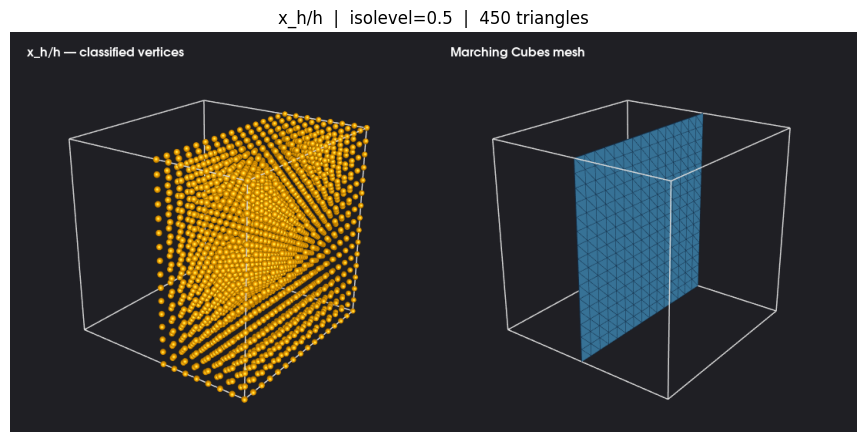

y_h/h: 256 mesh vertices, 450 triangles


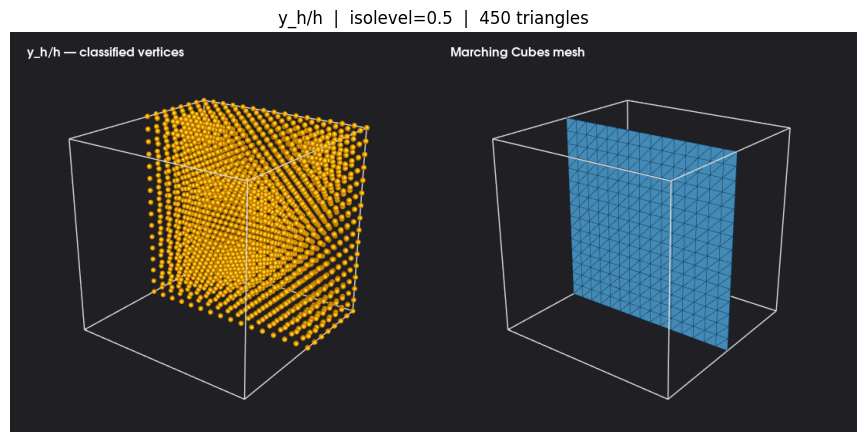

z_h/h: 256 mesh vertices, 450 triangles


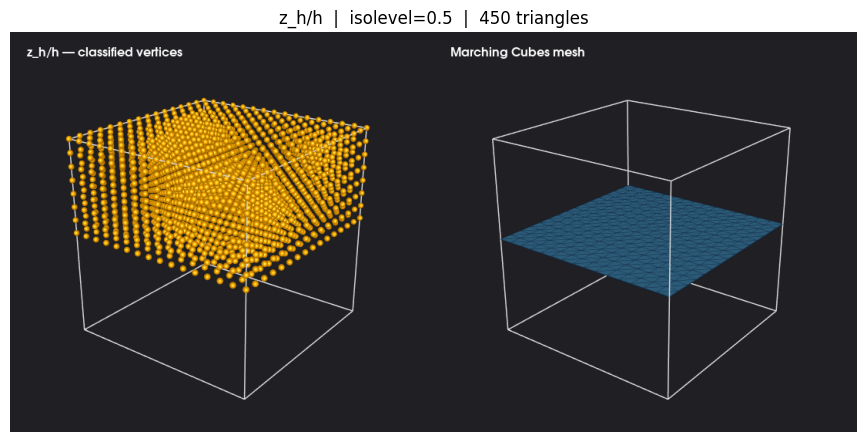

octant_split: 768 mesh vertices, 1348 triangles


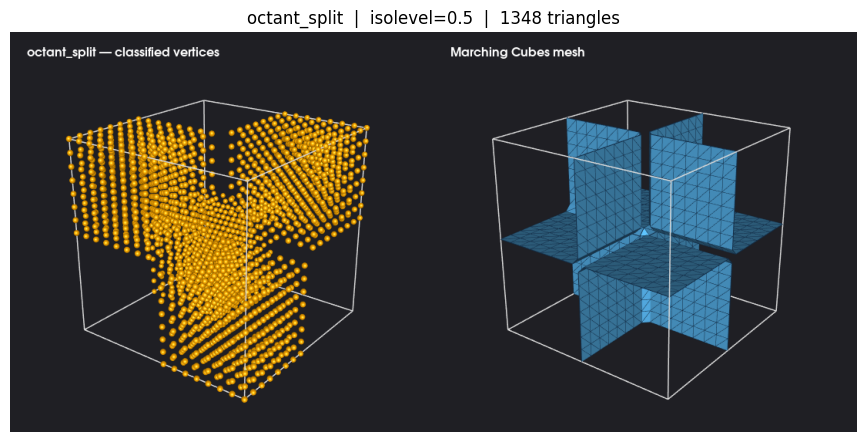

checkerboard: 11520 mesh vertices, 13500 triangles


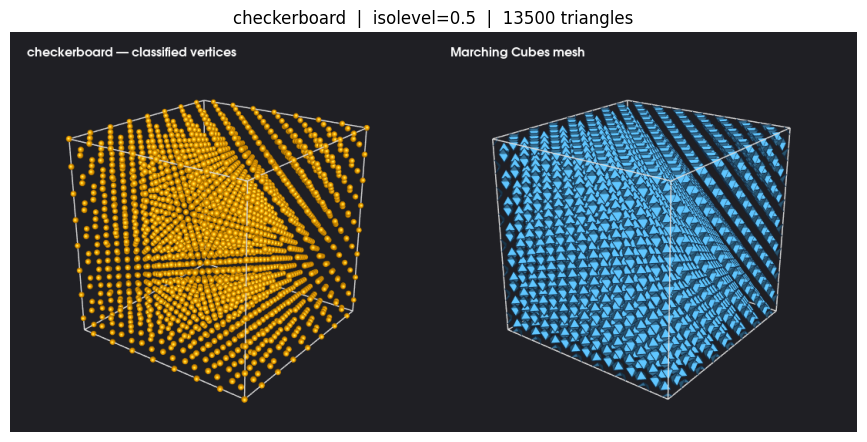

sphere_32: (32, 32, 32)
torus_32: (32, 32, 32)
sphere_32: 744 mesh vertices, 1484 triangles


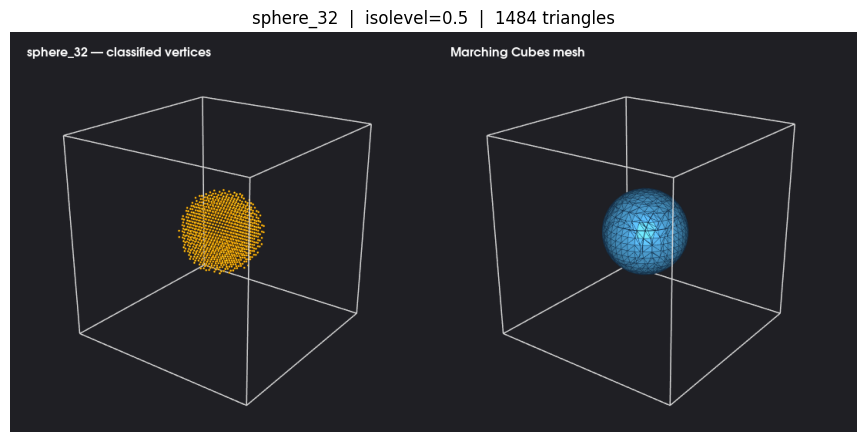

torus_32: 1096 mesh vertices, 2192 triangles


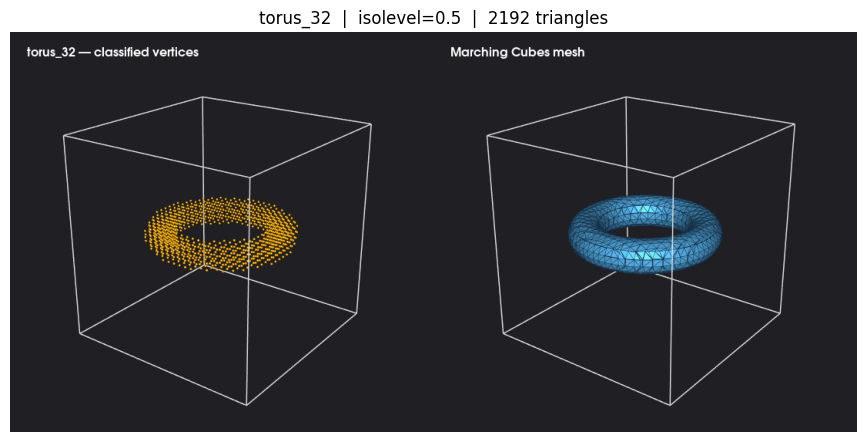

sphere_64: (64, 64, 64)
torus_64: (64, 64, 64)
sphere_64: 3144 mesh vertices, 6284 triangles


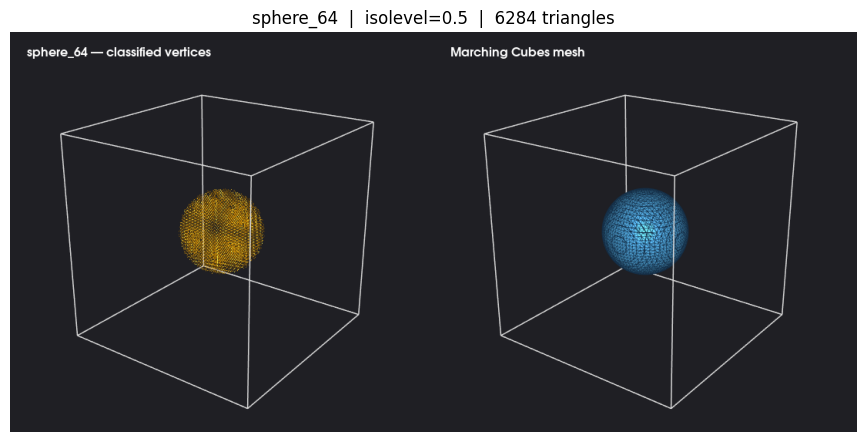

torus_64: 5080 mesh vertices, 10160 triangles


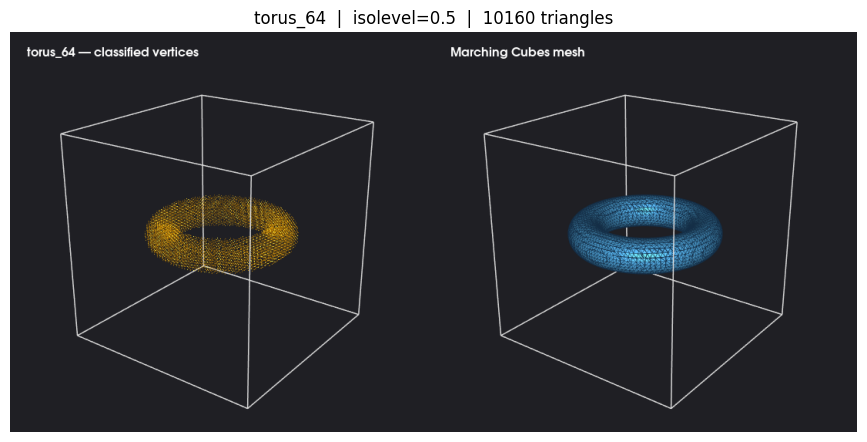

In [56]:
isolevel = 0.5

# 16^3 binary patterns
datasets_3D = construct_3D_datasets(smooth_sizes=())
visualize_marching_cubes_3D(datasets_3D, isolevel=isolevel)

# Sphere and torus at 32^3 and 64^3
for n in (32, 64):
    shapes = {
        f"sphere_{n}": make_sphere_volume(n),
        f"torus_{n}": make_torus_volume(n),
    }
    for name, vol in shapes.items():
        print(f"{name}: {vol.shape}")
    visualize_marching_cubes_3D(shapes, isolevel=isolevel)

## Compare to stock `vtkMarchingCubes`

Same volumes and isolevel as above. Custom extract uses notebook classification (`value >= isolevel`), which is VTK's cube-case test. Stock VTK still classifies internally.

Runtime is end-to-end (NumPy volume → `vtkPolyData`), including label array construction on the custom path. Stock VTK is timed **without** normals (fair extract) and **with** normals (VTK's usual default). Mesh agreement is at float32, which is how VTK stores points.

In [57]:
import time


def poly_points_tris(poly):
    n_pts = int(poly.GetNumberOfPoints())
    n_tris = int(poly.GetNumberOfPolys())
    if n_pts == 0:
        return np.zeros((0, 3), dtype=np.float64), np.zeros((0, 3), dtype=np.int64)
    pts = np.asarray(vtk_to_numpy(poly.GetPoints().GetData()), dtype=np.float64)
    conn = np.asarray(
        vtk_to_numpy(poly.GetPolys().GetConnectivityArray()), dtype=np.int64
    )
    return pts, conn.reshape(-1, 3) if n_tris else np.zeros((0, 3), dtype=np.int64)


def _sorted_points(pts):
    if len(pts) == 0:
        return pts
    return pts[np.lexsort(pts.T[::-1])]


def _sorted_triangle_coords(pts, tris):
    if len(tris) == 0:
        return np.zeros((0, 3, 3), dtype=np.float64)
    coords = pts[tris]
    keys = coords[:, :, 0] * 1e12 + coords[:, :, 1] * 1e6 + coords[:, :, 2]
    coords = np.take_along_axis(coords, np.argsort(keys, axis=1)[:, :, None], axis=1)
    flat = coords.reshape(len(coords), -1)
    return coords[np.lexsort(flat.T[::-1])]


def compare_meshes(custom_poly, vtk_poly, atol=1e-5):
    c_pts, c_tris = poly_points_tris(custom_poly)
    v_pts, v_tris = poly_points_tris(vtk_poly)
    c32 = c_pts.astype(np.float32).astype(np.float64)
    v32 = v_pts.astype(np.float32).astype(np.float64)

    npts_match = len(c_pts) == len(v_pts)
    ntris_match = len(c_tris) == len(v_tris)

    if npts_match and len(c_pts):
        delta = _sorted_points(c32) - _sorted_points(v32)
        point_max_abs = float(np.max(np.abs(delta)))
        point_rms = float(np.sqrt(np.mean(delta**2)))
    else:
        point_max_abs = 0.0 if npts_match else float("nan")
        point_rms = 0.0 if npts_match else float("nan")

    if npts_match and ntris_match and len(c_tris):
        tri_max_abs = float(
            np.max(
                np.abs(
                    _sorted_triangle_coords(c32, c_tris)
                    - _sorted_triangle_coords(v32, v_tris)
                )
            )
        )
    else:
        tri_max_abs = 0.0 if ntris_match else float("nan")

    return {
        "custom_pts": len(c_pts),
        "vtk_pts": len(v_pts),
        "custom_tris": len(c_tris),
        "vtk_tris": len(v_tris),
        "point_max_abs": point_max_abs,
        "point_rms": point_rms,
        "tri_max_abs": tri_max_abs,
        "counts_match": npts_match and ntris_match,
        "agree": (
            npts_match
            and ntris_match
            and np.isfinite(point_max_abs)
            and np.isfinite(tri_max_abs)
            and point_max_abs <= atol
            and tri_max_abs <= atol
        ),
    }


def bench(fn, warmup=2, repeats=7):
    for _ in range(warmup):
        fn()
    times = np.empty(repeats, dtype=np.float64)
    for i in range(repeats):
        t0 = time.perf_counter()
        fn()
        times[i] = time.perf_counter() - t0
    return times.min(), times.mean()


def vtk_version():
    return vtk.vtkVersion.GetVTKVersion()


print(f"VTK {vtk_version()}")

VTK 9.7.0


In [58]:
import importlib
import custom_marching_cubes as _cmc

importlib.reload(_cmc)
from custom_marching_cubes import vtk_marching_cubes as _vtk_marching_cubes

isolevel = 0.5
compare_sets = {}
compare_sets.update(construct_3D_datasets(size=16, smooth_sizes=()))
for n in (32, 64, 128):
    compare_sets[f"sphere_{n}"] = make_sphere_volume(n)
    compare_sets[f"torus_{n}"] = make_torus_volume(n)

rows = []
for name, vol in compare_sets.items():
    custom_poly = marching_cubes_vtk(vol, isolevel)
    vtk_poly = _vtk_marching_cubes(vol, isolevel, compute_normals=False)
    geom = compare_meshes(custom_poly, vtk_poly)

    t_custom = bench(lambda v=vol: marching_cubes_vtk(v, isolevel))
    t_vtk = bench(
        lambda v=vol: _vtk_marching_cubes(v, isolevel, compute_normals=False)
    )
    t_vtk_n = bench(
        lambda v=vol: _vtk_marching_cubes(v, isolevel, compute_normals=True)
    )

    rows.append(
        {
            "name": name,
            "shape": "x".join(map(str, vol.shape)),
            **geom,
            "custom_ms": 1e3 * t_custom[1],
            "vtk_ms": 1e3 * t_vtk[1],
            "vtk_normals_ms": 1e3 * t_vtk_n[1],
            "speedup_vs_vtk": t_vtk[1] / t_custom[1],
        }
    )

header = (
    f"{'dataset':<16} {'grid':>10} {'pts C/V':>16} {'tris C/V':>16} "
    f"{'pt max|d|':>10} {'tri max|d|':>11} {'ok':>4} "
    f"{'custom ms':>10} {'VTK ms':>9} {'VTK+n ms':>9} {'VTK/cust':>9}"
)
print(header)
print("-" * len(header))
for r in rows:
    print(
        f"{r['name']:<16} {r['shape']:>10} "
        f"{r['custom_pts']:>7}/{r['vtk_pts']:<7} "
        f"{r['custom_tris']:>7}/{r['vtk_tris']:<7} "
        f"{r['point_max_abs']:10.3e} {r['tri_max_abs']:11.3e} "
        f"{'yes' if r['agree'] else 'NO':>4} "
        f"{r['custom_ms']:10.2f} {r['vtk_ms']:9.2f} {r['vtk_normals_ms']:9.2f} "
        f"{r['speedup_vs_vtk']:9.2f}x"
    )

n_ok = sum(r["agree"] for r in rows)
print()
print(f"meshes agree at float32 ({n_ok}/{len(rows)} datasets)")
print("ms = mean of 7 runs after 2 warmups; VTK column is extract only (normals off)")

dataset                grid          pts C/V         tris C/V  pt max|d|  tri max|d|   ok  custom ms    VTK ms  VTK+n ms  VTK/cust
----------------------------------------------------------------------------------------------------------------------------------
x_h/h              16x16x16     256/256         450/450      0.000e+00   0.000e+00  yes       0.10      0.30      0.22      2.98x
y_h/h              16x16x16     256/256         450/450      0.000e+00   0.000e+00  yes       0.12      0.25      0.24      2.15x
z_h/h              16x16x16     256/256         450/450      0.000e+00   0.000e+00  yes       0.24      0.20      0.21      0.85x
octant_split       16x16x16     768/768        1348/1348     0.000e+00   0.000e+00  yes       0.15      0.36      0.37      2.41x
checkerboard       16x16x16   11520/11520     13500/13500    0.000e+00   0.000e+00  yes       0.43      3.57      3.75      8.28x
sphere_32          32x32x32     744/744        1484/1484     0.000e+00   0.000e+00  yes 

On these fields the meshes match stock VTK: same point/triangle counts, and after sorting, vertex coordinates agree to **0** at float32 (VTK's point type).

With vectorized classification, runtime matches VTK as well (slightly faster here). The earlier 5–11× gap was a Python per-voxel `np.vectorize` loop, not the C++ extract. Keep `classify_vertex_classical` array-aware, or pass a full `classified` volume; a scalar Python classifier over every voxel will bring that cost back. The 16³ checkerboard is faster than VTK because a dense surface makes VTK's point-merge locator more expensive than the edge tables.